# Atividade Prática – Inteligência Artificial

## Linguagem Natural, Mineração de Textos e Visualização de Dados

### Contextualização

Empresas que lidam com grandes volumes de dados textuais, como avaliações e comentários de clientes, precisam de ferramentas capazes de
transformar textos em informações visuais e compreensíveis.

A Inteligência Artificial, por meio do Processamento de Linguagem Natural (PLN) e da Mineração de Textos
, possibilita identificar padrões nesses textos. Já a visualização de dados
, por meio de gráficos, facilita a análise e a tomada de decisões. Nesta atividade, você irá analisar comentários de clientes armazenados em um arquivo CSV, utilizando Python, e representar os resultados graficamente, permitindo uma interpretação mais clara do perfil das clientes.

### Objetivo da Atividade

Aplicar conceitos de: 
- Inteligência Artificial
- Linguagem Natural
- Mineração de Textos 
- Visualização de Dados

para identificar e representar graficamente as palavras mais utilizadas pelas clientes, traçando um perfil geral a partir dos comentários analisados.

Arquivo utilizado:

clientes_keego.csv

O arquivo contém
 
300 registros de clientes, com as colunas:
 
cliente_id
comentario (texto em linguagem natural)

In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from collections import Counter
import matplotlib.pyplot as plt

### Parte 1 – Importação e Exploração dos Dados

1. Importar o arquivo clientes_keego.csv utilizando a biblioteca pandas

2. Visualizar as primeiras linhas do dataset.

3. Identificar a coluna que contém os textos a serem analisados.

Conceitos envolvidos:

Dados reais, leitura de dados, IA aplicada a bases textuais.

In [2]:
df = pd.read_csv('clientes_keego.csv')

display(df.head())

coluna_texto = 'comentario'
print(f"\nA coluna que contém os textos a serem analisados é: '{coluna_texto}'")

,cliente_id,comentario
0,1,Produto chegou com atraso
1,2,Produto recebido
2,3,Produto de excelente qualidade
3,4,Produto chegou rápido e bem embalado
4,5,Produto recebido



A coluna que contém os textos a serem analisados é: 'comentario'


### Parte 2 – Preparação do Texto (PLN)

1. Unir todos os comentários em um único texto.

2. Converter todo o texto para letras minúsculas.

1. Realizar a tokenização, separando o texto em palavras.

4. Remover palavras irrelevantes (stopwords).

Conceitos envolvidos:

Linguagem Natural, pré-processamento de texto, tokenização.

In [6]:
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pablohenriquecardosoramos/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/pablohenriquecardosoramos/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pablohenriquecardosoramos/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
# 1. Unir todos os comentários em um único texto
texto_completo = " ".join(df['comentario'].dropna().tolist())

# 2. Converter todo o texto para letras minúsculas
texto_min = texto_completo.lower()

# 3. Realizar a tokenização (separar em palavras)
tokens = word_tokenize(texto_min, language='portuguese')

# 4. Remover palavras irrelevantes (stopwords) e pontuações
stop_words_pt = set(stopwords.words('portuguese'))
pontuacoes = set(string.punctuation)

# Filtrando palavras que sejam alfabéticas e não sejam stopwords
palavras_limpas = [
    palavra for palavra in tokens 
    if palavra not in stop_words_pt 
    and palavra not in pontuacoes 
    and palavra.isalpha()
]

print(f"Total de palavras após a limpeza: {len(palavras_limpas)}")

Total de palavras após a limpeza: 815


### Parte 3 – Mineração de Textos

1. Realizar a contagem da frequência das palavras relevantes.
2. Selecionar as 10 palavras mais frequentes nos comentários.

Conceitos envolvidos:

Mineração de Textos, identificação de padrões, análise de frequência.


In [8]:
# 1. Contagem da frequência das palavras
frequencia = Counter(palavras_limpas)

# 2. Selecionar as 10 palavras mais frequentes
palavras_top10 = dict(frequencia.most_common(10))

print("As 10 palavras mais frequentes são:")
for palavra, qtd in palavras_top10.items():
    print(f"{palavra}: {qtd}")

As 10 palavras mais frequentes são:
produto: 132
atendimento: 110
qualidade: 71
gostei: 50
compra: 39
chegou: 37
padrão: 31
rápido: 27
excelente: 26
recebido: 25


### Parte 4 – Visualização dos Resultados (Plotagem)

1. Gerar um gráfico de barras representando as palavras mais frequentes e suas respectivas quantidades.

2. Identificar visualmente quais termos aparecem com maior destaque.

4. Utilizar o gráfico para auxiliar a interpretação do perfil das clientes.
 
Conceitos envolvidos:

Visualização de dados, interpretação visual, apoio à tomada de decisão.

Exemplo de Plotagem (Referência)

´´´

import matplotlib.pyplot as plt

#### Selecionando as 10 palavras mais frequentes

palavras = dict(frequencia.most_common(10))

plt.bar(palavras.keys(), palavras.values())

plt.title("Palavras mais frequentes nos comentários das clientes")

plt.xlabel("Palavras")

plt.ylabel("Frequência")

plt.xticks(rotation=45)

plt.show()

´´´
 
Relação com IA:

A IA extrai os padrões (palavras), e a visualização transforma esses padrões em informação clara e compreensível.


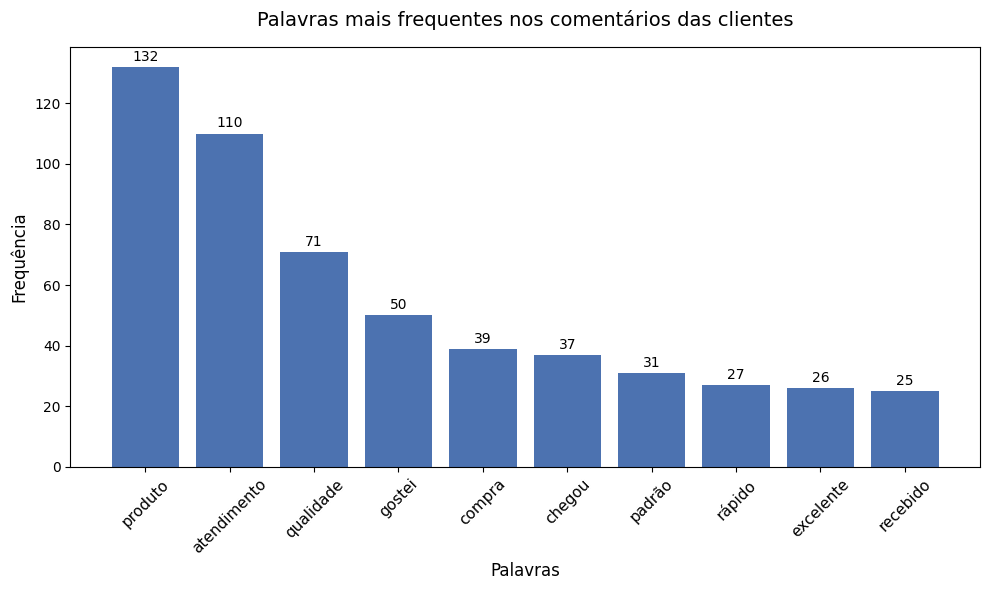

In [9]:
palavras = palavras_top10

plt.figure(figsize=(10, 6))
bars = plt.bar(palavras.keys(), palavras.values(), color='#4C72B0')

plt.title("Palavras mais frequentes nos comentários das clientes", fontsize=14, pad=15)
plt.xlabel("Palavras", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.xticks(rotation=45, fontsize=11)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, yval, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Parte 5 – Análise do Perfil das Clientes

1. Com base no gráfico gerado, descreva o perfil geral das clientes.
    
    O gráfico revela que as clientes da Keego possuem um perfil atento à experiência de compra como um todo. Elas não focam apenas no item físico, mas dão enorme peso à forma como são tratadas e à logística da operação.

2. Identifique se os comentários indicam uma percepção mais positiva, negativa ou neutra.

    percepção geral é positiva. A presença de palavras com forte carga de aprovação, como "gostei" e "excelente", somadas à ausência de termos negativos no top 10 (como "ruim", "demorou" ou "defeito"), indica um alto nível de satisfação.

3. Destaque quais aspectos são mais valorizados (produto, atendimento, qualidade, tempo de entrega, etc.).

    O Produto e sua Qualidade ("produto", "qualidade", "padrão").

    O Atendimento ao Cliente (segunda palavra mais citada, indicando que o suporte faz muita diferença para esse público).

    A Logística/Entrega ("chegou", "rápido", "recebido").

Conceitos envolvidos:

Interpretação de dados, IA aplicada a negócios, análise crítica.

Conclusão da Atividade (Produção do Aluno)

Ao final desta atividade, o aluno deverá elaborar um resumo explicativo, com suas próprias palavras, demonstrando o entendimento adquirido ao longo do processo. Nesse resumo, o aluno deverá:

Relacionar o uso do Python como ferramenta de apoio à Inteligência Artificial;
Explicar como a Linguagem Natural aparece nos comentários das clientes;
Descrever a importância do Processamento de Linguagem Natural (PLN) no preparo dos textos (tokenização, normalização e remoção de stopwords);
Apontar como a Mineração de Textos permitiu identificar padrões por meio da frequência das palavras;
Explicar o papel da visualização de dados (gráfico) na interpretação dos resultados;
Apresentar sua percepção sobre o perfil das clientes, com base nos resultados obtidos.
O resumo deve demonstrar que o aluno compreendeu que a Inteligência Artificial não substitui a análise humana, mas atua como uma
ferramenta capaz de processar grandes volumes de dados, extrair informações relevantes e apoiar a tomada de decisões a partir de dados textuais.